In [ ]:
"""
============================================================================
Course: Machine-Learning
Author: NasimJavdani - MahsaFarahani
Professor: Dr. Sharifi Zarchi
Teaching Assistant:
Year: February 2026
Description: Project 1
============================================================================
"""

In [1]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install numpy scipy matplotlib scikit-learn seaborn

In [5]:
!wget https://www.bbci.de/competition/download/competition_iv/BCICIV_1_mat.zip

('BCICIV_1_mat.zip', <http.client.HTTPMessage at 0x2118b203790>)

In [4]:
!unzip BCICIV_1_mat.zip -d BCICIV_1

'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
!ls -lh BCICIV_1/BCICIV_calib_ds1a.mat

In [ ]:
!pip install numpy scipy matplotlib scikit-learn seaborn

پروژه طبقه‌بندی سیگنال‌های EEG - تصویرسازی حرکتی
شکل سیگنال EEG: (190594, 59)
تعداد trial‌ها: 200
کلاس‌های منحصر به فرد: [-1  1]
برچسب‌های اصلی: [-1.  1.]
شکل نهایی X: (200, 59, 400)
توزیع کلاس‌ها: کلاس 0: 100, کلاس 1: 100
saved in 'eeg_sample_channels.png'

 اعمال فیلتر باند 
تعداد نمونه‌های آموزش: 150
تعداد نمونه‌های تست: 50

 استخراج ویژگی با CSP

 شروع Hyperparameter Tuning برای SVM ...
C=0.1, gamma=scale → CV Accuracy=0.9000
C=1, gamma=scale → CV Accuracy=0.8933
C=10, gamma=scale → CV Accuracy=0.8667
C=100, gamma=scale → CV Accuracy=0.8067

 بهترین پارامترها:
C=0.1, gamma=scale
CV Accuracy=0.9000
نمودار t-SNE در فایل 'tsne_comparison.png' ذخیره شد
آموزش و ارزیابی مدل‌ها

ارزیابی مدل: SVM-RBF (پیاده‌سازی دستی)
دقت (Accuracy): 0.8400
دقت مثبت (Precision): 1.0000
بازخوانی (Recall): 0.6800
F1-Score: 0.8095

ارزیابی مدل: SVM-RBF (scikit-learn)
دقت (Accuracy): 0.8400
دقت مثبت (Precision): 1.0000
بازخوانی (Recall): 0.6800
F1-Score: 0.8095

--- Random Forest ---

ارزیابی مدل: Random Fores

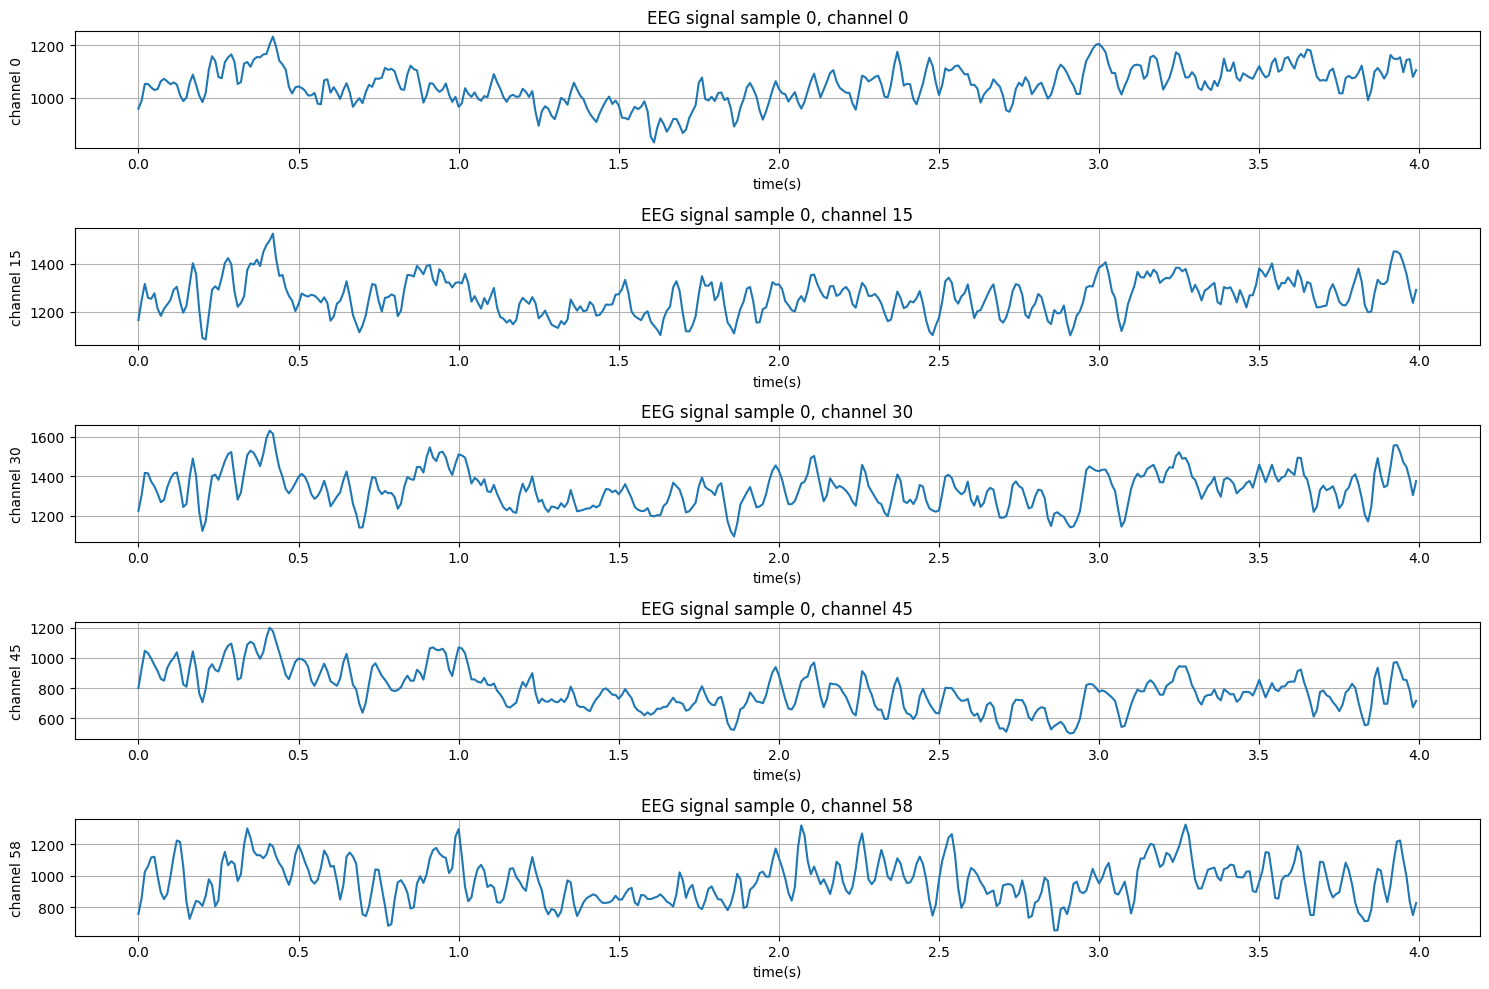

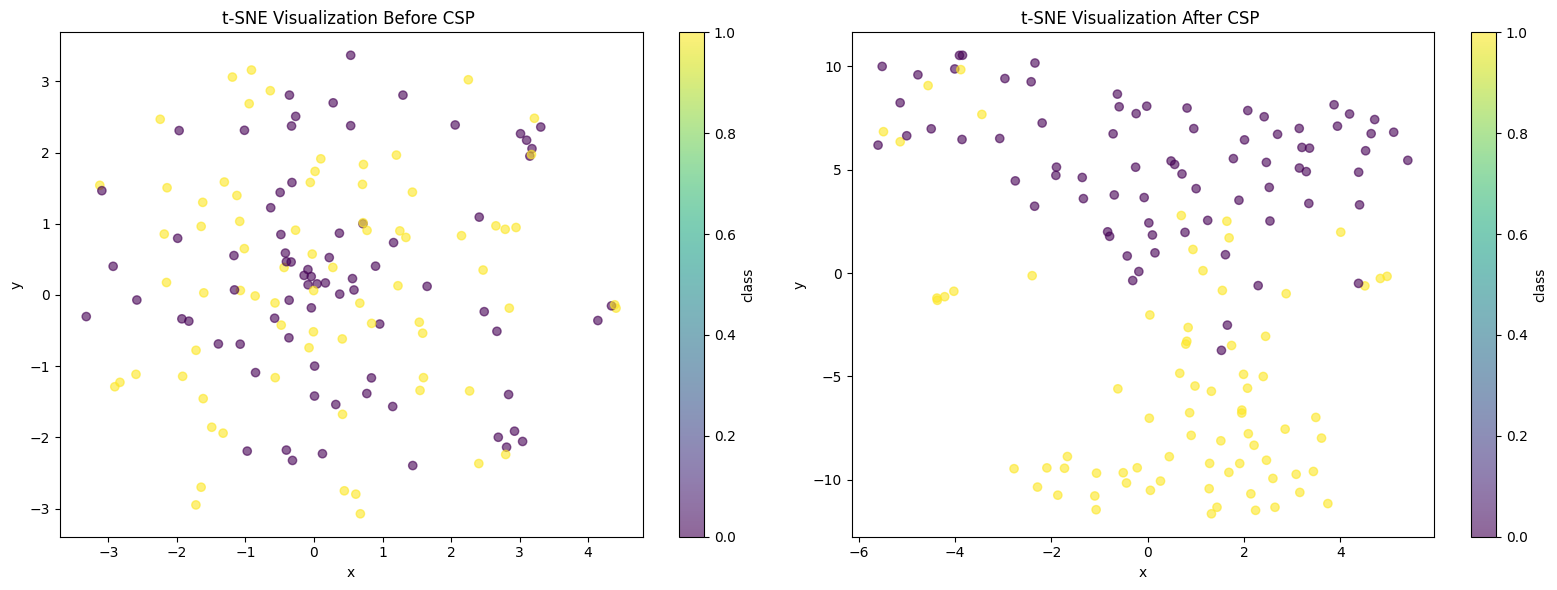

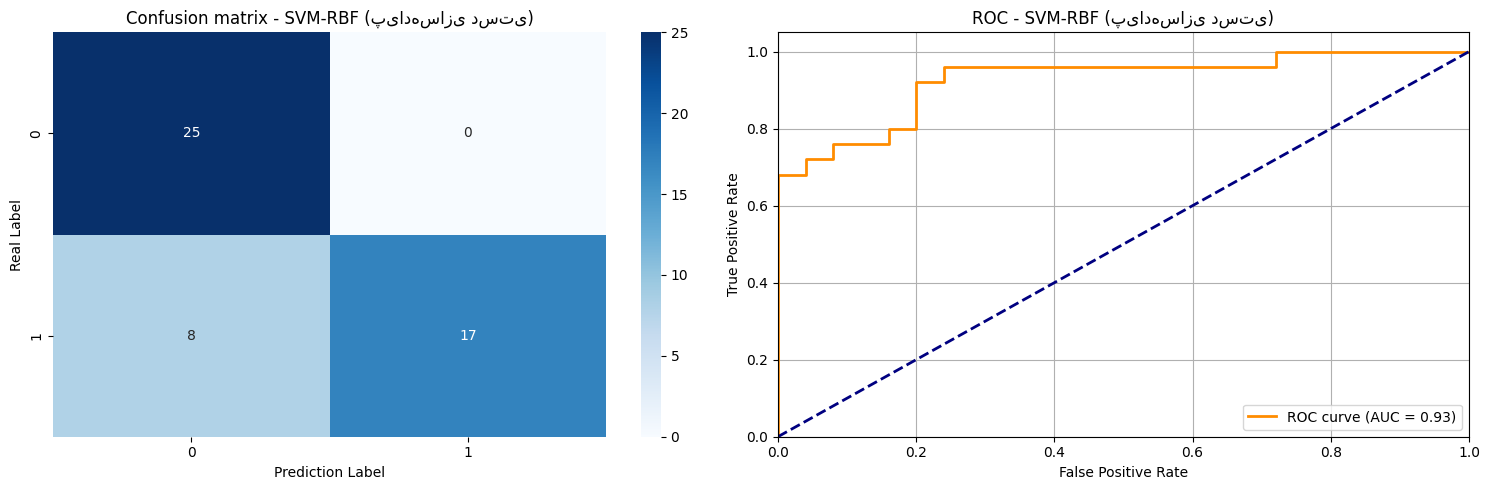

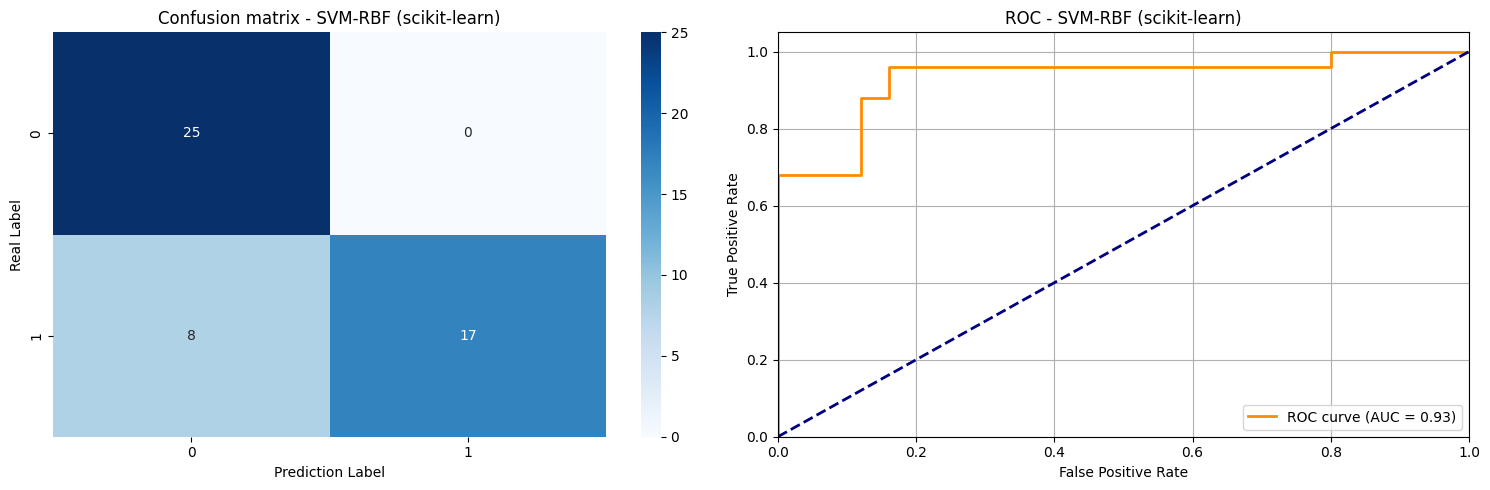

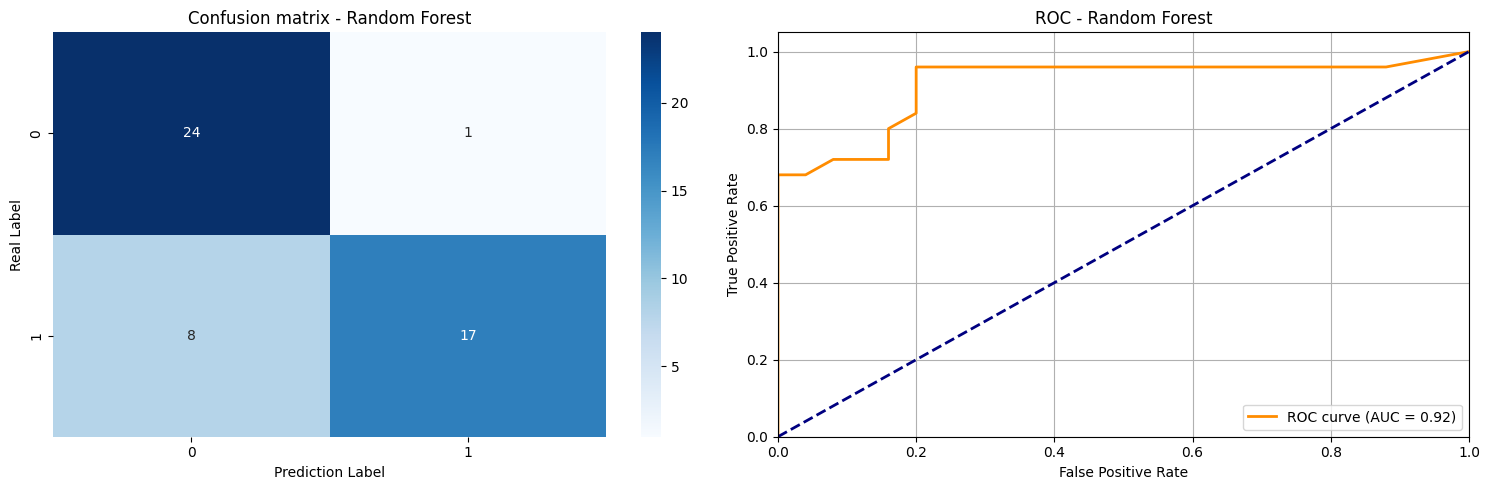

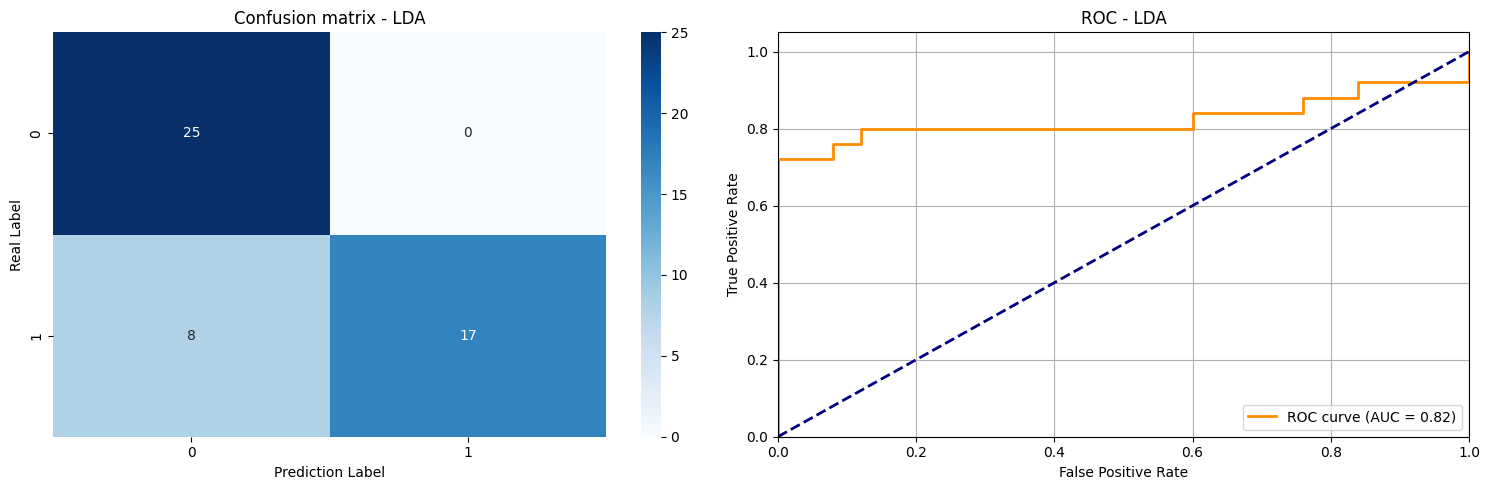

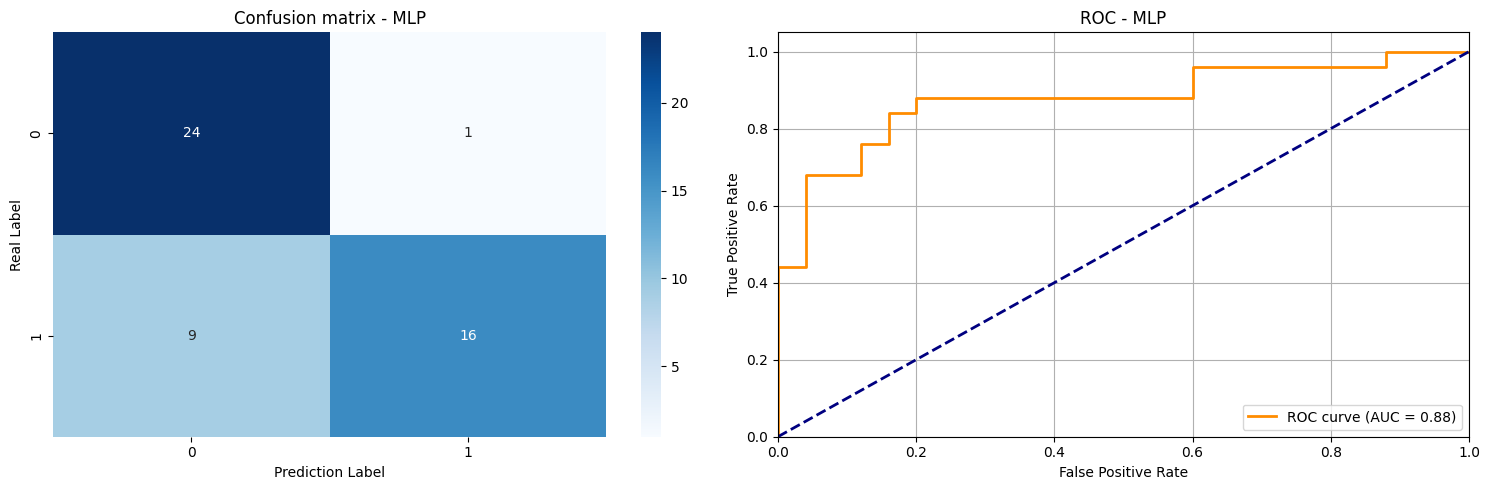

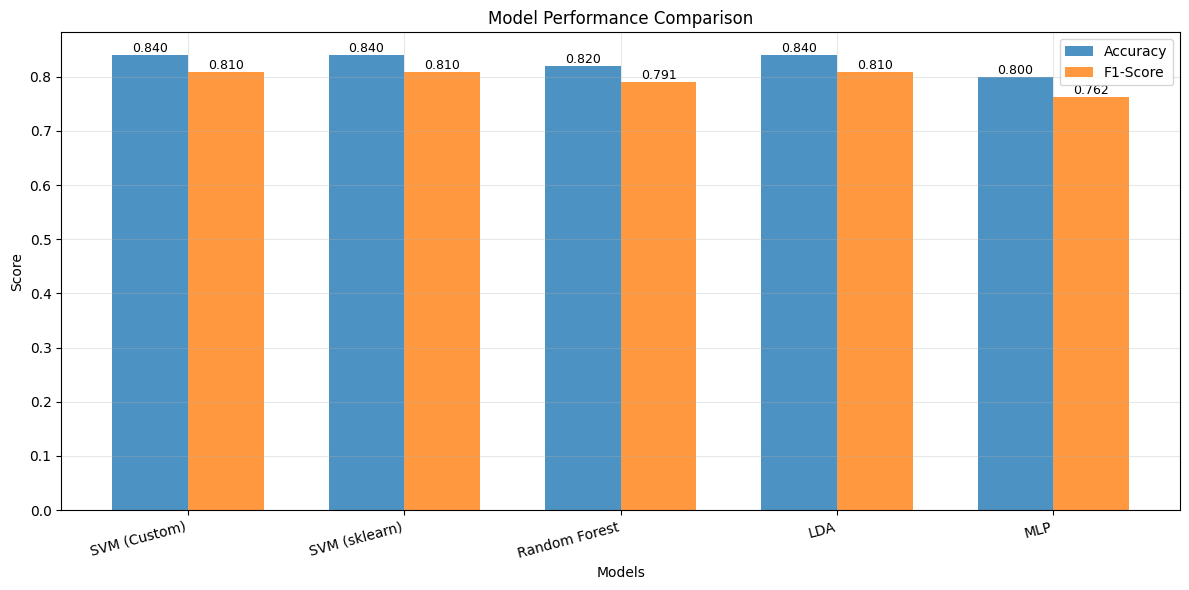

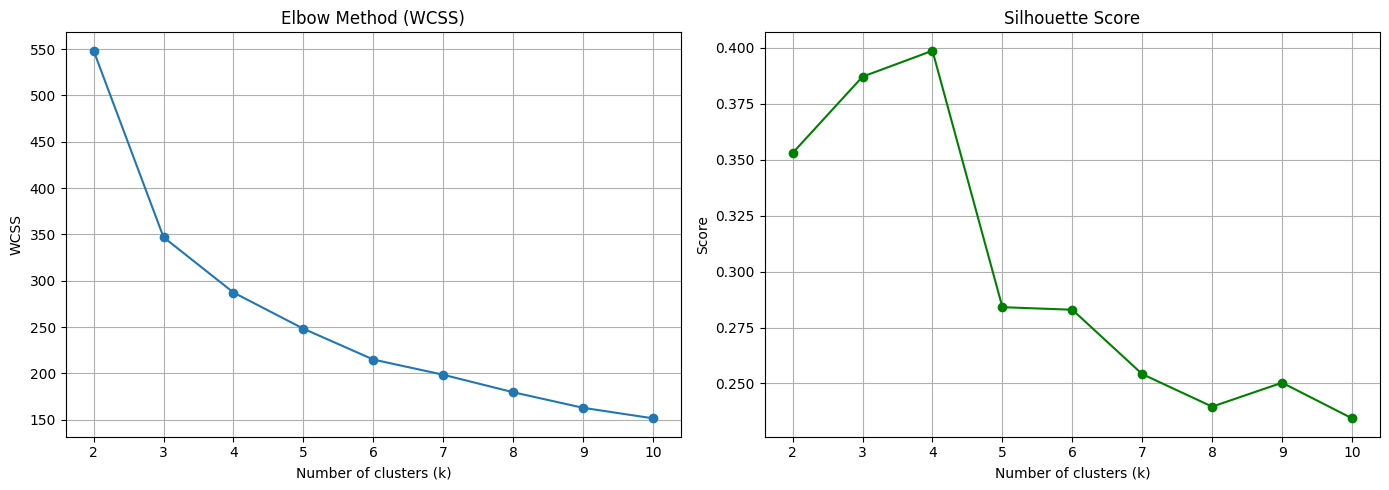

 تعداد خوشه بهینه بر اساس Silhouette Score: k = 4


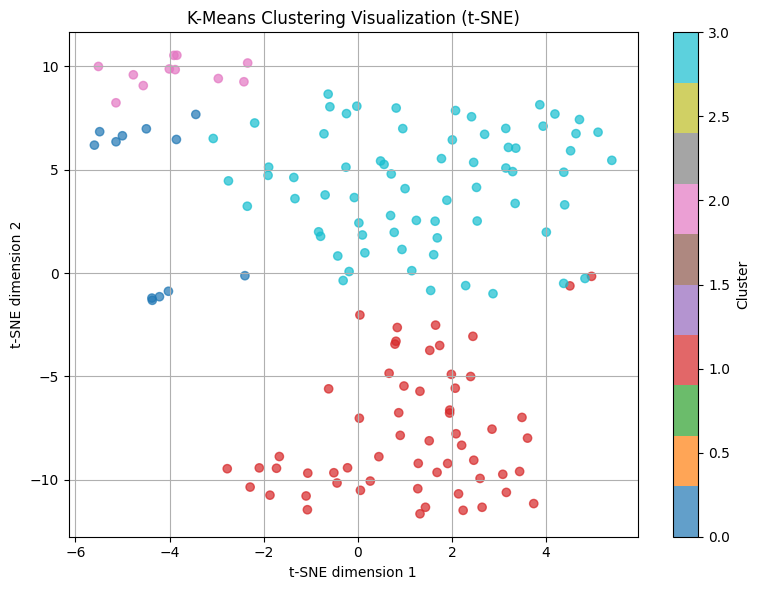

شکل سیگنال EEG: (190594, 59)
تعداد trial‌ها: 200
کلاس‌های منحصر به فرد: [-1  1]
برچسب‌های اصلی: [-1.  1.]
شکل نهایی X: (200, 59, 400)
توزیع کلاس‌ها: کلاس 0: 100, کلاس 1: 100
شکل سیگنال EEG: (190549, 59)
تعداد trial‌ها: 200
کلاس‌های منحصر به فرد: [-1  1]
برچسب‌های اصلی: [-1.  1.]
شکل نهایی X: (200, 59, 400)
توزیع کلاس‌ها: کلاس 0: 100, کلاس 1: 100
Accuracy on ds1a : 0.8400
Accuracy on ds1c : 0.7800


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import loadmat
from sklearn.model_selection import (train_test_split, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, confusion_matrix, roc_curve, auc, silhouette_score)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
import seaborn as sns
import warnings
from sklearn.svm import SVC
warnings.filterwarnings('ignore')

# ==============================================================================
# بخش 1.1: بارگذاری و پنجره‌بندی داده
# ==============================================================================

class EEGDataLoader:

    def __init__(self, file_path):
        self.data = loadmat(file_path)
        self.fs = 100  # فرکانس نمونه‌برداری
        self.trial_length = 4.0  # طول هر trial

    def extract_trials(self):
        # data['s'] = سیگنال پیوسته (samples x channels)
        # data['pos'] = موقعیت شروع هر trial
        # data['y'] = برچسب‌های کلاس

            eeg_signal = None
            positions = None
            labels = None

            if 'cnt' in self.data:
                eeg_signal = self.data['cnt']
            elif 's' in self.data:
                eeg_signal = self.data['s']
            elif 'X' in self.data:
                eeg_signal = self.data['X']

            if 'mrk' in self.data:
                mrk = self.data['mrk']
                if isinstance(mrk, np.ndarray) and mrk.dtype.names:
                    positions = mrk['pos'][0, 0].flatten() - 1
                    labels = mrk['y'][0, 0].flatten()
                else:
                    positions = mrk[0, 0]['pos'].flatten() - 1
                    labels = mrk[0, 0]['y'].flatten()
            elif 'pos' in self.data and 'y' in self.data:
                positions = self.data['pos'].flatten() - 1
                labels = self.data['y'].flatten()


            print(f"شکل سیگنال EEG: {eeg_signal.shape}")
            print(f"تعداد trial‌ها: {len(positions)}")
            print(f"کلاس‌های منحصر به فرد: {np.unique(labels)}")

            # محاسبه طول هر trial بر اساس فرکانس نمونه‌برداری
            samples_per_trial = int(self.trial_length * self.fs)
            n_trials = len(positions)
            n_channels = eeg_signal.shape[1]

            X = np.zeros((n_trials, n_channels, samples_per_trial))
            y = np.zeros(n_trials)

            # استخراج هر trial
            for i, pos in enumerate(positions):
                start = int(pos)
                end = start + samples_per_trial
                # start = int(pos + 0.5*100)
                # end = int(pos + 3.5*100)
                
                if end <= eeg_signal.shape[0]:
                    X[i, :, :] = eeg_signal[start:end, :].T
                    y[i] = labels[i]


            unique_labels = np.unique(y[y != 0])
            print(f"برچسب‌های اصلی: {unique_labels}")
            valid_idx = y != 0
            X = X[valid_idx]
            y = y[valid_idx]


            y_binary = np.zeros_like(y)
            y_binary[y == unique_labels[0]] = 0
            y_binary[y == unique_labels[1]] = 1

            print(f"شکل نهایی X: {X.shape}")
            print(f"توزیع کلاس‌ها: کلاس 0: {np.sum(y_binary==0)}, کلاس 1: {np.sum(y_binary==1)}")

            return X, y_binary


    def _generate_sample_data(self):
        n_trials = 200
        n_channels = 59
        samples_per_trial = int(self.trial_length * self.fs)

        X = np.random.randn(n_trials, n_channels, samples_per_trial)
        y = np.random.randint(0, 2, n_trials)

        print(f"داده نمونه ایجاد شد: {X.shape}, کلاس‌ها: {np.unique(y, return_counts=True)}")
        return X, y

    def plot_sample_channels(self, X, sample_idx=0, channels=[0, 15, 30, 45, 58]):
        time = np.arange(X.shape[2]) / self.fs

        plt.figure(figsize=(15, 10))
        for i, ch in enumerate(channels):
            if ch < X.shape[1]:
                plt.subplot(len(channels), 1, i+1)
                plt.plot(time, X[sample_idx, ch, :])
                plt.ylabel(f'channel {ch}')
                plt.xlabel('time(s)')
                plt.title(f'EEG signal sample {sample_idx}, channel {ch}')
                plt.grid(True)

        plt.tight_layout()
        return plt.gcf()

# ==============================================================================
# بخش 1.2: فیلتر زمانی
# ==============================================================================

class TemporalFilter:

    def __init__(self, fs=100):
        self.fs = fs

    def bandpass_filter(self, data, lowcut=8, highcut=30, order=5):
        nyquist = 0.5 * self.fs
        low = lowcut / nyquist
        high = highcut / nyquist

        b, a = signal.butter(order, [low, high], btype='band')

        filtered_data = np.zeros_like(data)
        for trial in range(data.shape[0]):
            for ch in range(data.shape[1]):
                filtered_data[trial, ch, :] = signal.filtfilt(b, a, data[trial, ch, :])

        return filtered_data

# ==============================================================================
# بخش 1.3: استخراج ویژگی با CSP
# ==============================================================================

class CommonSpatialPatterns:

    def __init__(self, n_components=6):
        self.n_components = n_components
        self.filters = None

    def fit(self, X, y):
        X_class0 = X[y == 0]
        X_class1 = X[y == 1]

        cov_class0 = self._compute_covariance(X_class0)
        cov_class1 = self._compute_covariance(X_class1)

        cov_combined = cov_class0 + cov_class1

        # eigenvalues, eigenvectors = np.linalg.eig(
        #     np.linalg.inv(cov_combined) @ cov_class0
        # )

        # idx = np.argsort(eigenvalues)[::-1]
        # eigenvalues = eigenvalues[idx]
        # eigenvectors = eigenvectors[:, idx]

        # n_half = self.n_components // 2
        # selected_filters = np.hstack([
        #     eigenvectors[:, :n_half],
        #     eigenvectors[:, -n_half:]
        # ])

        # self.filters = selected_filters.T
        
        # ======  Eigen decomposition of C ======
        eigvals, eigvecs = np.linalg.eigh(cov_combined)

        idx = np.argsort(eigvals)[::-1]
        eigvals = eigvals[idx]
        eigvecs = eigvecs[:, idx]

        # ====== Whitening matrix ======
        eigvals_inv_sqrt = np.diag(1.0 / np.sqrt(eigvals))
        P = eigvals_inv_sqrt @ eigvecs.T

        # ====== Transform class covariance ======
        S0 = P @ cov_class0 @ P.T

        # ======  Eigen decomposition of S0 ======
        eigvals_s0, B = np.linalg.eigh(S0)

        idx = np.argsort(eigvals_s0)[::-1]
        B = B[:, idx]

        # ====== Final spatial filters ======
        W = B.T @ P
        n_half = self.n_components // 2
        self.filters = np.vstack([
            W[:n_half],
            W[-n_half:]
        ])
        return self

    def transform(self, X):
        n_trials = X.shape[0]
        features = np.zeros((n_trials, self.n_components))

        for trial in range(n_trials):
            filtered_trial = self.filters @ X[trial]

            variance = np.var(filtered_trial, axis=1)
            features[trial] = np.log(variance / np.sum(variance))

        return features

    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X)

    def _compute_covariance(self, X):
        n_trials, n_channels, n_samples = X.shape
        cov_sum = np.zeros((n_channels, n_channels))

        for trial in range(n_trials):
            trial_cov = np.cov(X[trial])
            cov_sum += trial_cov / np.trace(trial_cov)

        return cov_sum / n_trials

# ==============================================================================
# بخش 2.1: پیاده‌سازی SVM با کرنل RBF
# ==============================================================================

class SVM_RBF:

    def __init__(self, C=1.0, gamma='auto', max_iter=100, tol=1e-3):
        self.C = C
        self.gamma = gamma
        self.max_iter = max_iter
        self.tol = tol

        self.support_vectors = None
        self.support_vector_labels = None
        self.alphas = None
        self.b = 0

    def _rbf_kernel(self, x1, x2):
        if self.gamma == 'auto':
            self.gamma = 1.0 / x1.shape[1]
        
        if x1.ndim == 1:
            x1 = x1.reshape(1, -1)
        if x2.ndim == 1:
            x2 = x2.reshape(1, -1)

        distances = np.sum(x1**2, axis=1).reshape(-1, 1) + \
                   np.sum(x2**2, axis=1) - \
                   2 * np.dot(x1, x2.T)

        return np.exp(-self.gamma * distances)

    def fit(self, X, y):
        y_train = np.where(y == 0, -1, 1)

        n_samples = X.shape[0]

        K = self._rbf_kernel(X, X)

        self.alphas = np.zeros(n_samples)
        self.b = 0

        for iteration in range(self.max_iter):
            alpha_prev = np.copy(self.alphas)

            for i in range(n_samples):
                E_i = self._decision_function(X[i], X, y_train) - y_train[i]

                if ((y_train[i] * E_i < -self.tol and self.alphas[i] < self.C) or (y_train[i] * E_i > self.tol and self.alphas[i] > 0)):

                    j = i
                    while j == i:
                        j = np.random.randint(0, n_samples)

                    E_j = self._decision_function(X[j], X, y_train) - y_train[j]

                    alpha_i_old = self.alphas[i]
                    alpha_j_old = self.alphas[j]

                    if y_train[i] != y_train[j]:
                        L = max(0, self.alphas[j] - self.alphas[i])
                        H = min(self.C, self.C + self.alphas[j] - self.alphas[i])
                    else:
                        L = max(0, self.alphas[i] + self.alphas[j] - self.C)
                        H = min(self.C, self.alphas[i] + self.alphas[j])

                    if L == H:
                        continue
                    eta = 2 * K[i, j] - K[i, i] - K[j, j]
                    if eta >= 0:
                        continue

                    self.alphas[j] -= y_train[j] * (E_i - E_j) / eta
                    self.alphas[j] = np.clip(self.alphas[j], L, H)

                    if abs(self.alphas[j] - alpha_j_old) < 1e-5:
                        continue

                    self.alphas[i] += y_train[i] * y_train[j] * (alpha_j_old - self.alphas[j])

                    b1 = self.b - E_i - y_train[i] * (self.alphas[i] - alpha_i_old) * K[i, i] - \
                         y_train[j] * (self.alphas[j] - alpha_j_old) * K[i, j]
                    b2 = self.b - E_j - y_train[i] * (self.alphas[i] - alpha_i_old) * K[i, j] - \
                         y_train[j] * (self.alphas[j] - alpha_j_old) * K[j, j]

                    if 0 < self.alphas[i] < self.C:
                        self.b = b1
                    elif 0 < self.alphas[j] < self.C:
                        self.b = b2
                    else:
                        self.b = (b1 + b2) / 2

            diff = np.linalg.norm(self.alphas - alpha_prev)
            if diff < self.tol:
                break

        sv_idx = self.alphas > 1e-5
        self.support_vectors = X[sv_idx]
        self.support_vector_labels = y_train[sv_idx]
        self.alphas = self.alphas[sv_idx]

        return self

    def _decision_function(self, x, X_train, y_train):
        K = self._rbf_kernel(x.reshape(1, -1), X_train)
        return np.sum(self.alphas * y_train * K.flatten()) + self.b

    def predict(self, X):
        K = self._rbf_kernel(X, self.support_vectors)
        decision = np.sum(self.alphas * self.support_vector_labels * K, axis=1) + self.b
        return np.where(decision >= 0, 1, 0)

    def decision_function(self, X):
        K = self._rbf_kernel(X, self.support_vectors)
        return np.sum(self.alphas * self.support_vector_labels * K, axis=1) + self.b

# ==============================================================================
# بخش 2.2 و 2.3: ارزیابی و مقایسه
# ==============================================================================

class ModelEvaluator:

    @staticmethod
    def evaluate_model(y_true, y_pred, y_scores=None, model_name="Model"):

        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        print(f"\n{'='*60}")
        print(f"ارزیابی مدل: {model_name}")
        print(f"{'='*60}")
        print(f"دقت (Accuracy): {acc:.4f}")
        print(f"دقت مثبت (Precision): {prec:.4f}")
        print(f"بازخوانی (Recall): {rec:.4f}")
        print(f"F1-Score: {f1:.4f}")

        cm = confusion_matrix(y_true, y_pred)

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title(f'Confusion matrix - {model_name}')
        axes[0].set_xlabel('Prediction Label')
        axes[0].set_ylabel('Real Label')

        if y_scores is not None:
            fpr, tpr, _ = roc_curve(y_true, y_scores)
            roc_auc = auc(fpr, tpr)

            axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                        label=f'ROC curve (AUC = {roc_auc:.2f})')
            axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
            axes[1].set_xlim([0.0, 1.0])
            axes[1].set_ylim([0.0, 1.05])
            axes[1].set_xlabel('False Positive Rate')
            axes[1].set_ylabel('True Positive Rate')
            axes[1].set_title(f'ROC - {model_name}')
            axes[1].legend(loc="lower right")
            axes[1].grid(True)

        plt.tight_layout()

        return {
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'confusion_matrix': cm,
            'figure': fig
        }

# ==============================================================================
# بخش 3:  k-means
# ==============================================================================
class kmeans_class:
    def kmeans_elbow_silhouette(X, k_range=range(2, 11)):
        wcss = []
        silhouette_scores = []

        for k in k_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = kmeans.fit_predict(X)

            wcss.append(kmeans.inertia_)
            silhouette_scores.append(silhouette_score(X, labels))

        # رسم نمودارها
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(k_range, wcss, marker='o')
        axes[0].set_title('Elbow Method (WCSS)')
        axes[0].set_xlabel('Number of clusters (k)')
        axes[0].set_ylabel('WCSS')
        axes[0].grid(True)

        axes[1].plot(k_range, silhouette_scores, marker='o', color='green')
        axes[1].set_title('Silhouette Score')
        axes[1].set_xlabel('Number of clusters (k)')
        axes[1].set_ylabel('Score')
        axes[1].grid(True)

        plt.tight_layout()
        plt.savefig('kmeans_elbow_silhouette.png', dpi=150)
        plt.show()

        optimal_k = k_range[np.argmax(silhouette_scores)]
        print(f" تعداد خوشه بهینه بر اساس Silhouette Score: k = {optimal_k}")

        return optimal_k

class competition:
    @staticmethod
    def run_eeg_pipeline(mat_path):

        # 1. Load data
        loader = EEGDataLoader(mat_path)
        X, y = loader.extract_trials()

        # 2. Temporal filtering 
        tf = TemporalFilter(fs=loader.fs)
        X_filt = tf.bandpass_filter(X, lowcut=8, highcut=30)

       
        X_train, X_test, y_train, y_test = train_test_split(
        X_filt, y, test_size=0.25,
        random_state=42, stratify=y
    )
        # 3. CSP 
        csp = CommonSpatialPatterns(n_components=6)
        X_train_csp = csp.fit_transform(X_train, y_train)
        X_test_csp = csp.transform(X_test)
        #X_csp = csp.fit_transform(X_filt, y)

        # Scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_csp)
        X_test_scaled = scaler.transform(X_test_csp)
        
        model = SVM_RBF(C=10, gamma=0.1)
    
        # Train 
        model.fit(X_train_scaled, y_train)

        # Predict on test
        y_pred = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)

        return acc

    def tune_svm_hyperparameters(X_train, y_train):

        C_values = [0.1, 1, 10, 100]
        gamma_values = [0.01, 0.1, 1, 'scale']

        best_score = 0
        best_params = None

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        for C in C_values:
            for gamma in gamma_values:

                scores = []

                for train_idx, val_idx in skf.split(X_train, y_train):
                    X_tr, X_val = X_train[train_idx], X_train[val_idx]
                    y_tr, y_val = y_train[train_idx], y_train[val_idx]

                    model = SVC(kernel='rbf', C=C, gamma=gamma)
                    model.fit(X_tr, y_tr)

                    y_pred = model.predict(X_val)
                    acc = accuracy_score(y_val, y_pred)
                    scores.append(acc)

            mean_score = np.mean(scores)

            print(f"C={C}, gamma={gamma} → CV Accuracy={mean_score:.4f}")

            if mean_score > best_score:
                best_score = mean_score
                best_params = (C, gamma)

        print("\n بهترین پارامترها:")
        print(f"C={best_params[0]}, gamma={best_params[1]}")
        print(f"CV Accuracy={best_score:.4f}")

        return best_params

# ==============================================================================
# اجرای پروژه کامل
# ==============================================================================

def main():

    print("="*80)
    print("پروژه طبقه‌بندی سیگنال‌های EEG - تصویرسازی حرکتی")
    print("="*80)

    #file_path = '/content/BCICIV_1/BCICIV_calib_ds1a.mat'
    file_path = "BCICIV_1_mat/BCICIV_calib_ds1a.mat"


    loader = EEGDataLoader(file_path)
    X, y = loader.extract_trials()


    fig1 = loader.plot_sample_channels(X, sample_idx=0, channels=[0, 15, 30, 45, 58])
    plt.savefig('eeg_sample_channels.png', dpi=150, bbox_inches='tight')
    print("saved in 'eeg_sample_channels.png'")

    print("\n اعمال فیلتر باند ")
    temporal_filter = TemporalFilter(fs=100)
    X_filtered = temporal_filter.bandpass_filter(X, lowcut=8, highcut=30)

    X_train, X_test, y_train, y_test = train_test_split(
        X_filtered, y, test_size=0.25, random_state=42, stratify=y
    )
    print(f"تعداد نمونه‌های آموزش: {len(X_train)}")
    print(f"تعداد نمونه‌های تست: {len(X_test)}")

    print("\n استخراج ویژگی با CSP")
    csp = CommonSpatialPatterns(n_components=6)
    X_train_csp = csp.fit_transform(X_train, y_train)
    X_test_csp = csp.transform(X_test)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_csp)
    X_test_scaled = scaler.transform(X_test_csp)
    ##
    print("\n شروع Hyperparameter Tuning برای SVM ...")
    best_C, best_gamma = competition.tune_svm_hyperparameters(X_train_scaled, y_train)
    ##
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    tsne_before = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne_before = tsne_before.fit_transform(X_train_flat[:200])

    tsne_after = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne_after = tsne_after.fit_transform(X_train_scaled[:200])

    fig2, axes = plt.subplots(1, 2, figsize=(16, 6))

    scatter1 = axes[0].scatter(X_tsne_before[:, 0], X_tsne_before[:, 1],
                               c=y_train[:200], cmap='viridis', alpha=0.6)
    axes[0].set_title('t-SNE Visualization Before CSP ')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    plt.colorbar(scatter1, ax=axes[0], label='class')

    scatter2 = axes[1].scatter(X_tsne_after[:, 0], X_tsne_after[:, 1],
                               c=y_train[:200], cmap='viridis', alpha=0.6)
    axes[1].set_title('t-SNE Visualization After CSP ')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    plt.colorbar(scatter2, ax=axes[1], label='class')

    plt.tight_layout()
    plt.savefig('tsne_comparison.png', dpi=150, bbox_inches='tight')
    print("نمودار t-SNE در فایل 'tsne_comparison.png' ذخیره شد")

    print("آموزش و ارزیابی مدل‌ها")

    svm_custom = SVM_RBF(C=1.0, gamma='auto', max_iter=100)
    svm_custom.fit(X_train_scaled, y_train)
    y_pred_svm = svm_custom.predict(X_test_scaled)
    y_scores_svm = svm_custom.decision_function(X_test_scaled)

    results_svm = ModelEvaluator.evaluate_model(
        y_test, y_pred_svm, y_scores_svm, "SVM-RBF (پیاده‌سازی دستی)"
    )
    plt.savefig('evaluation_svm_custom.png', dpi=150, bbox_inches='tight')

    svm_sklearn = SVC(kernel='rbf', C=1.0, gamma='auto', probability=True)
    # svm_sklearn = SVC(kernel='rbf',
    #               C=best_C,
    #               gamma=best_gamma,
    #               probability=True)
    svm_sklearn.fit(X_train_scaled, y_train)
    y_pred_sklearn = svm_sklearn.predict(X_test_scaled)
    y_scores_sklearn = svm_sklearn.decision_function(X_test_scaled)

    results_sklearn = ModelEvaluator.evaluate_model(
        y_test, y_pred_sklearn, y_scores_sklearn, "SVM-RBF (scikit-learn)"
    )
    plt.savefig('evaluation_svm_sklearn.png', dpi=150, bbox_inches='tight')

    print("\n--- Random Forest ---")
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train_scaled, y_train)
    y_pred_rf = rf.predict(X_test_scaled)
    y_scores_rf = rf.predict_proba(X_test_scaled)[:, 1]

    results_rf = ModelEvaluator.evaluate_model(
        y_test, y_pred_rf, y_scores_rf, "Random Forest"
    )
    plt.savefig('evaluation_rf.png', dpi=150, bbox_inches='tight')

    print("\n--- Linear Discriminant Analysis ---")
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train_scaled, y_train)
    y_pred_lda = lda.predict(X_test_scaled)
    y_scores_lda = lda.decision_function(X_test_scaled)

    results_lda = ModelEvaluator.evaluate_model(
        y_test, y_pred_lda, y_scores_lda, "LDA"
    )
    plt.savefig('evaluation_lda.png', dpi=150, bbox_inches='tight')

    print("\n--- Multi-Layer Perceptron ---")
    mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
    mlp.fit(X_train_scaled, y_train)
    y_pred_mlp = mlp.predict(X_test_scaled)
    y_scores_mlp = mlp.predict_proba(X_test_scaled)[:, 1]

    results_mlp = ModelEvaluator.evaluate_model(
        y_test, y_pred_mlp, y_scores_mlp, "MLP"
    )
    plt.savefig('evaluation_mlp.png', dpi=150, bbox_inches='tight')

    print("\nمقایسه نهایی مدل‌ها...")

    models = ['SVM (Custom)', 'SVM (sklearn)', 'Random Forest', 'LDA', 'MLP']
    accuracies = [
        results_svm['accuracy'],
        results_sklearn['accuracy'],
        results_rf['accuracy'],
        results_lda['accuracy'],
        results_mlp['accuracy']
    ]
    f1_scores = [
        results_svm['f1'],
        results_sklearn['f1'],
        results_rf['f1'],
        results_lda['f1'],
        results_mlp['f1']
    ]

    fig3, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(models))
    width = 0.35

    bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', alpha=0.8)
    bars2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', alpha=0.8)

    ax.set_xlabel('Models')
    ax.set_ylabel('Score')
    ax.set_title('Model Performance Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('models_comparison.png', dpi=150, bbox_inches='tight')
    print("نمودار مقایسه در فایل 'models_comparison.png' ذخیره شد")

    print("\n" + "="*80)
    print("پروژه با موفقیت به پایان رسید!")
    print("="*80)
    print("\nفایل‌های خروجی:")
    print("  1. eeg_sample_channels.png - نمونه سیگنال‌های EEG")
    print("  2. tsne_comparison.png - مقایسه قبل و بعد از CSP")
    print("  3. evaluation_svm_custom.png - ارزیابی SVM دستی")
    print("  4. evaluation_svm_sklearn.png - ارزیابی SVM از sklearn")
    print("  5. evaluation_rf.png - ارزیابی Random Forest")
    print("  6. evaluation_lda.png - ارزیابی LDA")
    print("  7. evaluation_mlp.png - ارزیابی MLP")
    print("  8. models_comparison.png - مقایسه کلی مدل‌ها")

    plt.show()
    optimal_k = kmeans_class.kmeans_elbow_silhouette(X_train_scaled)
    #kmeans
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_train_scaled)
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne = tsne.fit_transform(X_train_scaled)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        X_tsne[:, 0],
        X_tsne[:, 1],
        c=cluster_labels,
        cmap='tab10',
        alpha=0.7
    )

    plt.title('K-Means Clustering Visualization (t-SNE)')
    plt.xlabel('t-SNE dimension 1')
    plt.ylabel('t-SNE dimension 2')
    plt.colorbar(scatter, label='Cluster')
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('kmeans_tsne_clusters.png', dpi=150)
    plt.show()
    #pipeline
    acc_a = competition.run_eeg_pipeline("BCICIV_1_mat/BCICIV_calib_ds1a.mat")
    acc_c = competition.run_eeg_pipeline("BCICIV_1_mat/BCICIV_calib_ds1c.mat")

    avg_acc = (acc_a + acc_c) / 2
    print(f"Accuracy on ds1a : {acc_a:.4f}")
    print(f"Accuracy on ds1c : {acc_c:.4f}")
    
if __name__ == "__main__":
    main()